### creating object with sync video and parse telemetry

In [72]:
import os
from collections import namedtuple
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import pickle

# --------------------------------------------------
# CONFIG
# --------------------------------------------------
DATA_DIR = "../Data/"
TARGET_FPS = 2.0
OUTPUT_PLAYBACK_FPS = 30.0
WIDTH = 960
HEIGHT = 540

pickle_path = os.path.join(DATA_DIR, "data.pkl")
video_path = os.path.join(DATA_DIR, "dji_20260502184301_0005_D.MP4")
output_path = os.path.join(DATA_DIR, "output.mp4")
csv_path = os.path.join(DATA_DIR, "dji_20260502184301_0005_d.csv")


In [ ]:
dataFrame = pd.read_csv(csv_path)

rawSampleTime = dataFrame["SampleTime"].astype(str).str.replace(" s", "").astype(float).to_numpy()
cumulativeTimeSec = rawSampleTime

timeStep = 1.0 / TARGET_FPS
targetTimestamps = np.arange(0, cumulativeTimeSec[-1], timeStep)

filterIndices = []
for targetTime in targetTimestamps:
    closestIndex = np.abs(cumulativeTimeSec - targetTime).argmin()
    if closestIndex not in filterIndices:
        filterIndices.append(closestIndex)

filteredDataFrame = dataFrame.iloc[filterIndices]

latitude = filteredDataFrame["GPSLatitude"].to_numpy()
longitude = filteredDataFrame["GPSLongitude"].to_numpy()
relAlt = filteredDataFrame["RelativeAltitude"].to_numpy()
absAlt = filteredDataFrame["AbsoluteAltitude"].to_numpy()

dronePitch = filteredDataFrame["DronePitch"].to_numpy()
droneRoll = filteredDataFrame["DroneRoll"].to_numpy()
droneYaw = -filteredDataFrame["DroneYaw"].to_numpy()

# gimbalPitch = filteredDataFrame["GimbalPitch"].to_numpy()
# gimbalRoll = filteredDataFrame["GimbalRoll"].to_numpy()
gimbalYaw = -filteredDataFrame["GimbalYaw"].to_numpy()

globalYaw = (droneYaw - gimbalYaw) % 360.0

In [85]:
baseName, ext = os.path.splitext(video_path)
compressed_video_path = f"{baseName}_{WIDTH}x{HEIGHT}{ext}"

if not os.path.exists(compressed_video_path):
    cap = cv2.VideoCapture(video_path)
    totalFrames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    videoWriter = cv2.VideoWriter(compressed_video_path, fourcc, OUTPUT_PLAYBACK_FPS, (WIDTH, HEIGHT))

    for _ in tqdm(range(totalFrames), desc="Compressing full video"):
        success, frame = cap.read()
        if not success:
            break
        resizedFrame = cv2.resize(frame, (WIDTH, HEIGHT), interpolation=cv2.INTER_AREA)
        videoWriter.write(resizedFrame)

    cap.release()
    videoWriter.release()

In [86]:
cap = cv2.VideoCapture(compressed_video_path)
extractedFrames = []

totalFrames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
targetFramesSet = set(filterIndices)

for currentFrameIdx in tqdm(range(totalFrames), desc="Extracting frames"):
    success, frame = cap.read()
    if not success:
        break
        
    if currentFrameIdx in targetFramesSet:
        extractedFrames.append(frame)
        
    if len(extractedFrames) == len(targetFramesSet):
        break

cap.release()
frames = np.array(extractedFrames)


Extracting frames:   0%|          | 0/1323 [00:00<?, ?it/s]

Extracting frames: 100%|█████████▉| 1319/1323 [00:01<00:00, 749.98it/s]


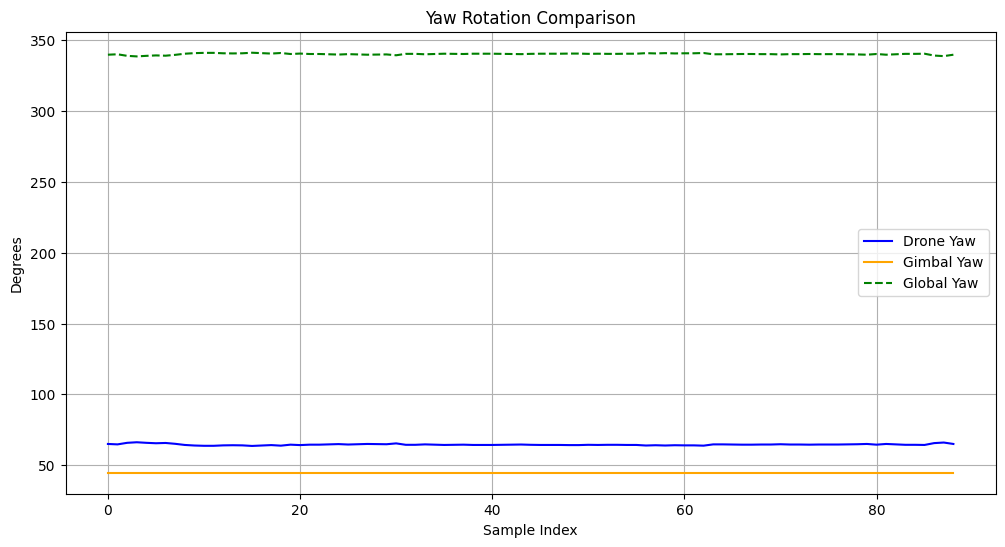

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot( droneYaw, label="Drone Yaw", color="blue")
plt.plot( gimbalYaw, label="Gimbal Yaw", color="orange")
plt.plot( globalYaw, label="Global Yaw", color="green", linestyle="--")
plt.title("Yaw Rotation Comparison")
plt.xlabel("Sample Index")
plt.ylabel("Degrees")
plt.grid(True)
plt.legend()
plt.show()

## Analyzing part

In [88]:
import numpy as np
import cv2



feature_params = dict(
    maxCorners=800,
    qualityLevel=0.03,
    minDistance=5,
    blockSize=5
)

lk_params = dict(
    winSize=(21, 21),      # bigger window for faster motion
    maxLevel=3,            # deeper pyramid for large movement
    criteria=(
        cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,
        30,
        0.01
    )
)


dx_list = []
dy_list = []

old_gray = cv2.cvtColor(frames[0], cv2.COLOR_BGR2GRAY)
p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)

for i in range(1, len(frames)):
    frame_gray = cv2.cvtColor(frames[i], cv2.COLOR_BGR2GRAY)

    # If no points to track, re-detect
    if p0 is None or len(p0) == 0:
        p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)
        if p0 is None:
            continue

    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)

    # If tracking failed completely, re-detect points and skip
    if p1 is None or st is None:
        old_gray = frame_gray
        p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)
        continue

    good_new = p1[st == 1]
    good_old = p0[st == 1]

    if len(good_new) == 0:
        old_gray = frame_gray
        p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)
        continue

    flow = good_new - good_old

    dx = np.median(flow[:, 0])
    dy = np.median(flow[:, 1])

    dx_list.append(dx)
    dy_list.append(dy)

    old_gray = frame_gray
    p0 = good_new.reshape(-1, 1, 2)

print("Done!")


Done!


In [89]:
import numpy as np

def remove_spikes_mad(x, thresh=30):
    x = np.asarray(x)
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    if mad == 0:
        return x
    z = 0.6745 * (x - med) / mad
    x_clean = x.copy()
    x_clean[np.abs(z) > thresh] = med
    return x_clean

# dx_list = remove_spikes_mad(dx_list)
# dy_list = remove_spikes_mad(dy_list)


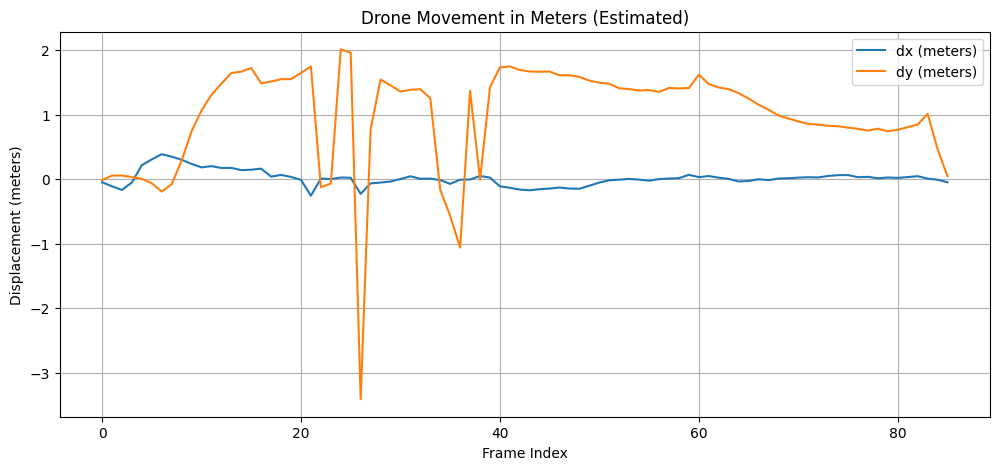

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# CONFIG & LOAD
# --------------------------------------------------
IMG_H = HEIGHT
focalLen = 24.0  
fov_rad = np.deg2rad(focalLen)
droneYawRad = np.radians(globalYaw)

# --------------------------------------------------
# CALCULATE METERS PER PIXEL
# --------------------------------------------------
meters_per_pixel = 2 * relAlt * np.tan(fov_rad / 2) / IMG_H

actual_length = min(len(dx_list), len(meters_per_pixel))
meters_per_pixel_trimmed = meters_per_pixel[:actual_length]

dx_m = np.array(dx_list[:actual_length]) * meters_per_pixel_trimmed
dy_m = np.array(dy_list[:actual_length]) * meters_per_pixel_trimmed

x = np.cumsum(dx_m)
y = np.cumsum(dy_m)

rotatedDxList = []
rotatedDyList = []

for i in range(actual_length):
    cosYaw = np.cos(droneYawRad[i])
    sinYaw = np.sin(droneYawRad[i])
    
    rotatedDx = dx_m[i] * cosYaw - dy_m[i] * sinYaw
    rotatedDy = dx_m[i] * sinYaw + dy_m[i] * cosYaw
    
    rotatedDxList.append(rotatedDx)
    rotatedDyList.append(rotatedDy)

x_global = np.cumsum(rotatedDxList)
y_global = np.cumsum(rotatedDyList)

# --------------------------------------------------
# PLOT DISPLACEMENT
# --------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(dx_m, label="dx (meters)")
plt.plot(dy_m, label="dy (meters)")
plt.title("Drone Movement in Meters (Estimated)")
plt.xlabel("Frame Index")
plt.ylabel("Displacement (meters)")
plt.legend()
plt.grid(True)
plt.show()


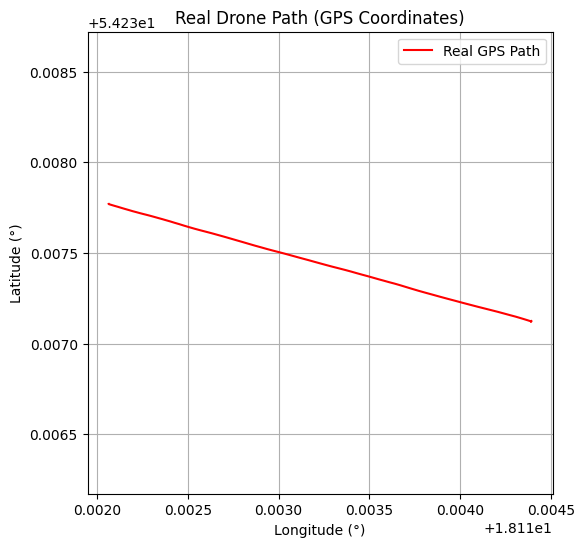

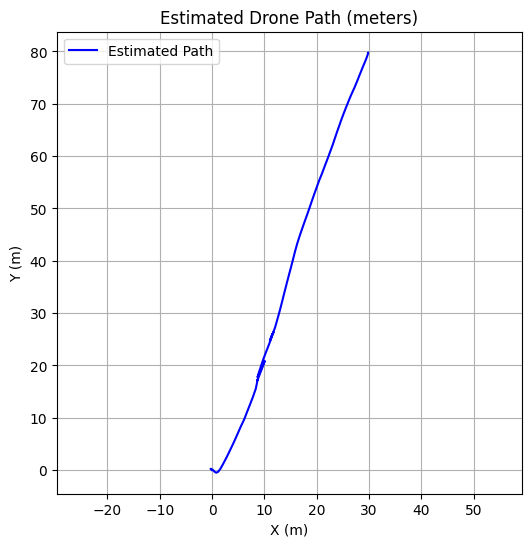

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.plot(longitude, latitude, color="red", label="Real GPS Path")
plt.title("Real Drone Path (GPS Coordinates)")
plt.xlabel("Longitude (°)")
plt.ylabel("Latitude (°)")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(x_global, y_global, color="blue", label="Estimated Path")
plt.title("Estimated Drone Path (meters)")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

In [81]:
print(droneYaw)

[65.  64.7 65.8 66.2 65.8 65.5 65.7 65.1 64.3 63.9 63.7 63.7 64.  64.1
 64.  63.6 63.9 64.2 63.8 64.5 64.2 64.5 64.5 64.7 64.9 64.6 64.8 65.
 64.9 64.8 65.4 64.4 64.4 64.7 64.5 64.3 64.4 64.5 64.3 64.3 64.3 64.4
 64.5 64.6 64.4 64.3 64.3 64.3 64.2 64.2 64.4 64.3 64.4 64.4 64.3 64.3
 63.9 64.1 63.9 64.1 64.  64.  63.8 64.7 64.7 64.6 64.5 64.5 64.6 64.6
 64.8 64.6 64.6 64.5 64.6 64.6 64.6 64.7 64.8 65.  64.5 65.  64.7 64.4
 64.4 64.3 65.6 66.  65. ]
